In [1]:
### Imports

import numpy as np
import torch
from database import open_feather, RENAL_DB_PATH, prepare_database, get_tabpfn_arrays, scale_df_data, compare_distributions, plot_deaths_distribution
from sae import train_sae_model
from tabpfn_model import fit_dr_tabpfn, walkforward_evaluate_tabpfn, TabPFNEvalConfig, load_or_extract_embeddings, EmbeddingExtractConfig, scale_embeddings, temporal_test_subsplits
from decision_tree import train_binary_trees, get_rules_forced
from tcav import train_cavs_from_rules, get_model_gradients, get_tcav_scores, run_feature_association_dual_split, run_sparse_readout_dual_split, get_significant_concepts
from filepaths import get_env_path
from pickle import dump, load
import os
import pandas as pd
from tabpfn import TabPFNClassifier
from results import cid10_dict, translate_event_names
import matplotlib.pyplot as plt
from sae_compare import run_sae_random_comparison, plot_run_results, calculate_concept_correlation_drift, plotar_termometro_drift
from instance_selection import infer_with_selected_instances
from dotenv import load_dotenv
load_dotenv()

False

In [2]:
### Tratamento de dados

PREPARED_DB_PATH = get_env_path('data/renal/prep.pkl')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
df = open_feather(RENAL_DB_PATH)
if not os.path.exists(PREPARED_DB_PATH):
    prep_out = prepare_database(df=df)
    tabpfn_arrays = get_tabpfn_arrays(prep_out)
    with open(PREPARED_DB_PATH, 'wb') as f:
        dump(prep_out, f)
else:
    with open(PREPARED_DB_PATH, 'rb') as f:
        prep_out = load(f)
        tabpfn_arrays = get_tabpfn_arrays(prep_out)

train_rows = prep_out['train_rows']
test_rows = prep_out['test_rows']
top_k_events = prep_out['top_k_events']
cid = cid10_dict()

X_train_np = tabpfn_arrays['X_train']
y_train_np = tabpfn_arrays['y_train']
years_train_np = tabpfn_arrays['years_train']

X_test_np = tabpfn_arrays['X_test']
y_test_np = tabpfn_arrays['y_test']
years_test_np = tabpfn_arrays['years_test']


feature_cols = list(np.asarray(top_k_events))
X_train_df = train_rows[feature_cols].copy()
X_test_df = test_rows[feature_cols].copy()

print(f'years_train: {years_train_np.shape}')
print(f'years_test: {years_test_np.shape}')
print("train_rows:", train_rows.shape)
print("test_rows :", test_rows.shape)
print("n top_k_events:", len(top_k_events))
print("train_years:", np.unique(years_train_np))
print("test_years :", np.unique(years_test_np))
print("X_train_np:", X_train_np.shape)
print("y_train_np:", y_train_np.shape, "| pos_ratio:", y_train_np.mean())

years_train: (9211,)
years_test: (21900,)
train_rows: (9211, 503)
test_rows : (21900, 503)
n top_k_events: 500
train_years: [1998 1999 2000 2001 2002 2003 2004 2005 2006]
test_years : [2007 2008 2009 2010 2011 2012 2013 2014 2015]
X_train_np: (9211, 500)
y_train_np: (9211,) | pos_ratio: 0.17424818152209315


In [3]:
### Avaliação de drift nos dados e (opcional) selecão de features estáveis

cut_features = False
data_shift_df, features_to_keep, features_to_keep_name = compare_distributions(x_i=X_train_np, x_j=X_test_np, top_k_events=top_k_events)

X_train_start = train_rows[train_rows['year'] == 2000][feature_cols].to_numpy()
X_train_end = train_rows[train_rows['year'] == max(years_train_np)][feature_cols].to_numpy()

data_shift_train, _, _ = compare_distributions(X_train_start, X_train_end, top_k_events)

X_test_start = test_rows[test_rows['year'] == min(years_test_np)][feature_cols].to_numpy()
X_test_end = test_rows[test_rows['year'] == max(years_test_np)][feature_cols].to_numpy()

data_shift_test, _, _ = compare_distributions(X_test_start, X_test_end, top_k_events)

data_shift_df.to_csv('stats/data_shift.csv')
data_shift_train.to_csv('stats/data_shift_train.csv')
data_shift_test.to_csv('stats/data_shift_test.csv')

if not cut_features:
    features_to_keep = np.ones(len(top_k_events), dtype=bool)
    features_to_keep_name = top_k_events

X_train_np = X_train_np[:, features_to_keep]
X_test_np = X_test_np[:, features_to_keep]

train_rows = train_rows[features_to_keep_name + ['patient_id', 'year', 'DEATH']]
test_rows = test_rows[features_to_keep_name + ['patient_id', 'year', 'DEATH']]

/home/joaosilveira/Projetos/SAE-TCAV/database.py:373: RuntimeWarning: divide by zero encountered in scalar divide
  'Mean ratio': max(mean_i[idx], mean_j[idx]) / min(mean_i[idx], mean_j[idx]),
/home/joaosilveira/Projetos/SAE-TCAV/database.py:374: RuntimeWarning: divide by zero encountered in scalar divide
  'Std ratio': max(std_i[idx], std_j[idx]) / min(std_i[idx], std_j[idx]),
/home/joaosilveira/Projetos/SAE-TCAV/.venv/lib/python3.10/site-packages/scipy/stats/_morestats.py:3057: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom
/home/joaosilveira/Projetos/SAE-TCAV/database.py:373: RuntimeWarning: invalid value encountered in scalar divide
  'Mean ratio': max(mean_i[idx], mean_j[idx]) / min(mean_i[idx], mean_j[idx]),
/home/joaosilveira/Projetos/SAE-TCAV/database.py:374: RuntimeWarning: invalid value encountered in scalar divide
  'Std ratio': max(std_i[idx], std_j[idx]) / min(std_i[idx], std_j[idx]),
/home/joaosilveira/Projetos/SAE-TCAV/database.py:373: Run

In [4]:
### Fit + avaliação de desempenho do TabPFN

eval_cfg = TabPFNEvalConfig()
fit_out = fit_dr_tabpfn(X_train_np, y_train_np, years_train_np, eval_cfg)

drift_model: TabPFNClassifier = fit_out["model"]
model_add_x_device = fit_out["model_add_x_device"]
example_add_shape = fit_out["example_add_shape"]

print(f"Fit time: {fit_out['fit_time_sec']:.2f}s")
print("additional_x device:", model_add_x_device)
print("example_add_shape:", example_add_shape)

wf = walkforward_evaluate_tabpfn(
    drift_model=drift_model,
    test_rows=test_rows,
    top_k_events=top_k_events,
    train_years=years_train_np,
    model_add_x_device=model_add_x_device,
    batch_size_predict=512,
    example_add_shape=example_add_shape,
    use_cache=True
)

results_per_year = wf["results_per_year"]
year_to_domain_combined = wf["year_to_domain_combined"]
test_rows_checked = wf["test_rows_checked"]

results_per_year_df = pd.DataFrame(results_per_year)
results_df = pd.DataFrame(results_per_year).sort_values("year").reset_index(drop=True)
print(results_df)

Initialized decoder for standard with (None, 10)  and nout 10


Fit time: 0.29s
additional_x device: cpu
example_add_shape: (9211, 1, 1)
Inferencias do ano 2007
Carregando resultados do arquivo salvo
Inferencias do ano 2008
Carregando resultados do arquivo salvo
Inferencias do ano 2009
Carregando resultados do arquivo salvo
Inferencias do ano 2010
Carregando resultados do arquivo salvo
Inferencias do ano 2011
Carregando resultados do arquivo salvo
Inferencias do ano 2012
Carregando resultados do arquivo salvo
Inferencias do ano 2013
Carregando resultados do arquivo salvo
Inferencias do ano 2014
Carregando resultados do arquivo salvo
Inferencias do ano 2015
Carregando resultados do arquivo salvo
   year  n_samples  n_deaths  f1_macro    f1_pos  infer_time_sec
0  2007       1894       143  0.631643  0.329412       80.693402
1  2008       2393       179  0.649559  0.368973      101.552176
2  2009       2485       219  0.664066  0.399240      102.934964
3  2010       2594       216  0.628659  0.335766      123.764069
4  2011       2520       258  0.618

In [5]:
### Extração de embeddings do TabPFN

emb_cfg = EmbeddingExtractConfig()
emb_cfg.use_cache = True
emb_out = load_or_extract_embeddings(
    model=drift_model,
    X_train_np=X_train_np,
    X_test_np=X_test_np,
    years_train=years_train_np,
    years_test=years_test_np,
    year_to_domain_map=year_to_domain_combined,
    embeddings_dir=None,
    cfg=emb_cfg,
    device=model_add_x_device,
    example_add_shape=example_add_shape,
)

train_emb = emb_out['train_emb_flat'].astype(np.float32)
test_emb = emb_out['test_emb_flat'].astype(np.float32)
train_emb_scaled, test_emb_scaled, scaler_emb = scale_embeddings(train_emb, test_emb, fit_test=False)

models/tabpfn/dr_tabpfn_train_emb.npy models/tabpfn/dr_tabpfn_test_emb.npy


KeyboardInterrupt: 

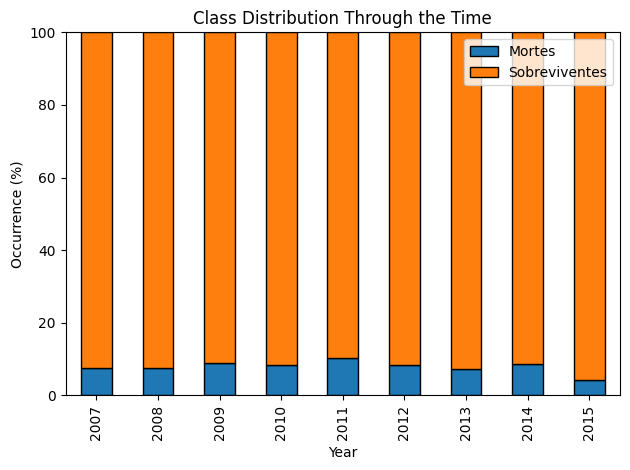

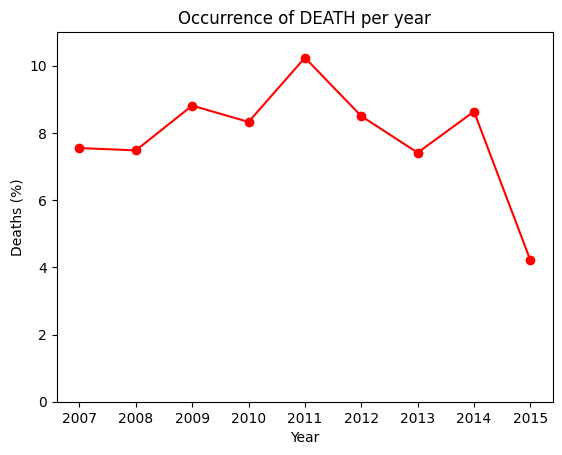

In [6]:
### Análise de drift de conceitos x degradação do modelo

plot_deaths_distribution(results_per_year)

full_df, dist_df = calculate_concept_correlation_drift(
    X_test_df=test_rows,
    test_embs=test_emb,
    test_years_np=years_test_np,
    features=feature_cols,
    alpha=1.0,
    undersample=True
)
plotar_termometro_drift(dist_df)

In [ ]:
### Teste do TabPFN com seleção de contexto

test_indices = range(0, len(test_rows))
np.random.seed(42)
infer_indices = np.random.choice(test_indices, size=50, replace=False)
X_infer_np = X_test_np[infer_indices, :]
y_infer_np = y_test_np[infer_indices]
years_infer_np = years_test_np[infer_indices]
data = infer_with_selected_instances(
    base_model=drift_model,
    base_sae=train_sae_model(inputs=torch.tensor(train_emb_scaled, dtype=torch.float32), save_data=False, use_cache=False, alpha=1.0),
    X_train_np=X_train_np,
    years_train_np=years_train_np,
    y_train_np=y_train_np,
    train_embs=train_emb_scaled,
    X_infer_np=X_infer_np,
    y_infer_np=y_infer_np,
    years_infer_np=years_infer_np,
    emb_scaler=scaler_emb,
    add_x_device=model_add_x_device,
    add_x_shape=example_add_shape
)
for key, val in data.items():
    print(f'{key}: {val}')

In [6]:
### Scaling e split dos dados

scaler, X_train_df_norm, X_test_df_norm = scale_df_data(
    X_train_df, X_test_df, feature_cols
)

print(f'X_train_df_norm: {X_train_df.shape}')
print(f'X_test_df_norm : {X_test_df.shape}')

y_test = (test_rows["DEATH"] > 0).astype(int).to_numpy(copy=True)
split_idx = temporal_test_subsplits(
    y_test,
    42
)

idx_test_discover = split_idx["idx_test_discover"]
idx_test_cav_train = split_idx["idx_test_cav_train"]
idx_test_tcav_eval = split_idx["idx_test_tcav_eval"]
idx_test_held_out = split_idx["idx_test_held_out"]

print("Discovery :", len(idx_test_discover), f"({len(idx_test_discover) / len(y_test):.1%})")
print("CAV Train :", len(idx_test_cav_train), f"({len(idx_test_cav_train) / len(y_test):.1%})")
print("TCAV Eval :", len(idx_test_tcav_eval), f"({len(idx_test_tcav_eval) / len(y_test):.1%})")
print("Held-out  :", len(idx_test_held_out), f"({len(idx_test_held_out) / len(y_test):.1%})")

y_test_discover = y_test[idx_test_discover]
y_test_cav_train = y_test[idx_test_cav_train]
y_test_tcav_eval = y_test[idx_test_tcav_eval]
y_test_held_out = y_test[idx_test_held_out]

years_test_discover = years_test_np[idx_test_discover]
years_test_cav_train = years_test_np[idx_test_cav_train]
years_test_tcav_eval = years_test_np[idx_test_tcav_eval]
years_test_held_out = years_test_np[idx_test_held_out]

emb_tcav_eval = test_emb_scaled[idx_test_tcav_eval]
emb_discovery = test_emb_scaled[idx_test_discover]

X_train_df_norm: (9211, 500)
X_test_df_norm : (21900, 500)
Discovery : 7227 (33.0%)
CAV Train : 7336 (33.5%)
TCAV Eval : 3668 (16.7%)
Held-out  : 3669 (16.8%)


Training 14 ReLU SAEs with Alpha = 1.0, Scaling Factor = 1.5
Salvando grafico em stats/sae/ReLU/good_pairs_cos_sim[Alpha=1.0,scale=1.5].png


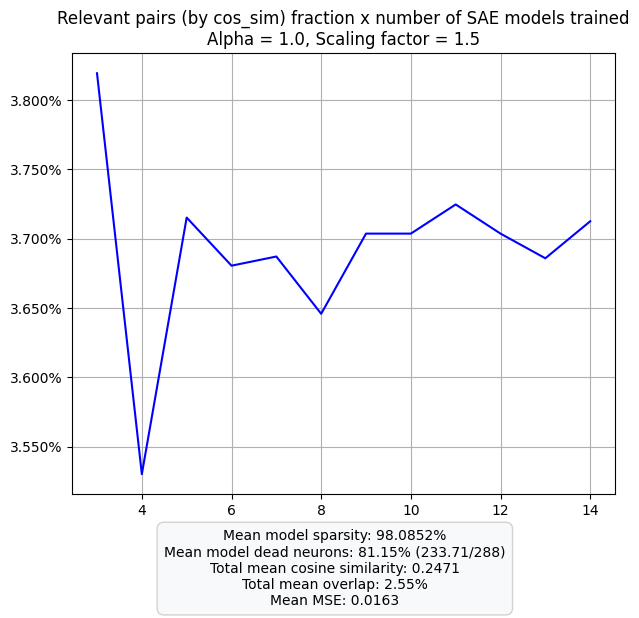

In [7]:
### Análise de retenção de conceitos do SAE em execuções aleatórias

inputs = emb_discovery
pair_criteria = 'cos_sim'
model_type = 'ReLU'
model_n = range(3, 15)
alphas = [1.0]
ks = [8]
scaling_factors = [1.5]

res, model_res, full_pair_df, sae_list = run_sae_random_comparison(
    model_nums=model_n,
    hyper_params=alphas if model_type == 'ReLU' else ks,
    embs=inputs, 
    scaling_factors=scaling_factors, 
    model_type=model_type,
    pair_criteria=pair_criteria,
)
pd.set_option('display.max_rows', 20)
full_pair_df['is_relevant_pair'] = full_pair_df[pair_criteria] >= 0.7
original_sae_df = full_pair_df[full_pair_df['sae_i_idx'] == 0].copy()

stats_by_concept = original_sae_df.groupby('original_concept').agg(
    survival_rate=('is_relevant_pair', 'mean'),
    mean_cos_sim=('cos_sim', 'mean'),
    mean_overlap=('overlap', 'mean')
).reset_index().sort_values('survival_rate', ascending=False)

surviving_concepts = stats_by_concept[stats_by_concept['survival_rate'] > 0.0]

pair_sae_idx = 1
original_sae_first_pairing_df = original_sae_df[original_sae_df['sae_j_idx'] == pair_sae_idx].copy()

first_pairing_survivors = original_sae_first_pairing_df[original_sae_first_pairing_df['is_relevant_pair'] == True]
original_survivors = first_pairing_survivors['original_concept'].tolist()
pairs = first_pairing_survivors['best_pair'].tolist()

with open(f'stats/concepts/surviving_concepts_{model_type}_sae.pkl', 'wb') as out:
    dump(surviving_concepts, out)
if model_type == 'ReLU':
    for alpha in alphas:
        plot_run_results(full_results=res, model_results=model_res, hyper_param=alpha,
                        scaling_factors=scaling_factors, model_n=model_n, pair_criteria=pair_criteria, model_type=model_type)
if model_type == 'TopK':
    for k in ks:
        plot_run_results(full_results=res, model_results=model_res, hyper_param=k,
                        scaling_factors=scaling_factors, model_n=model_n, pair_criteria=pair_criteria, model_type=model_type)
        
codes_train_tensor = []
codes_test_tensor = []
for s in sae_list:
    model = s['model']
    if model_type == 'TopK':
        sae_codes_train = model.encode(x=torch.tensor(inputs))[1].cpu().detach().numpy()
        sae_codes_test = model.encode(torch.tensor(test_emb_scaled[idx_test_cav_train]))[1].cpu().detach().numpy()
    else:
        sae_codes_train = model.encode(x=torch.tensor(inputs)).cpu().detach().numpy()
        sae_codes_test = model.encode(torch.tensor(test_emb_scaled[idx_test_cav_train])).cpu().detach().numpy()
    
    codes_train_tensor.append(sae_codes_train)
    codes_test_tensor.append(sae_codes_test)

codes_train_tensor = np.asarray(codes_train_tensor, dtype=np.float32)
codes_test_tensor = np.asarray(codes_test_tensor, dtype=np.float32)

In [8]:
### SAE usado no pipeline

sae = sae_list[0]['model']
sae_codes_train = codes_train_tensor[0]
sae_codes_test = codes_test_tensor[0]

sparsity_level = (sae_codes_train <= 1e-5).mean()
active_per_sample = (sae_codes_train > 1e-5).sum(axis=1).mean()

print(f'SAE codes (discovery): {sae_codes_train.shape}')
print(f"SAE near-zero activations: {sparsity_level:.2%}")
print(f"SAE active neurons/sample: {active_per_sample:.2f} / {sae_codes_train.shape[1]}")
print(f"SAE mean abs activation: {np.abs(sae_codes_train).mean():.4f}")
print(f"SAE max activation: {sae_codes_train.max():.4f}")
print(f'SAE dead neurons: {np.all(sae_codes_train <= 1e-5, axis=0).sum().item()}')

SAE codes (discovery): (7227, 288)
SAE near-zero activations: 98.06%
SAE active neurons/sample: 5.59 / 288
SAE mean abs activation: 0.1211
SAE max activation: 28.9556
SAE dead neurons: 225


In [9]:
### Árvores de decisão

rng = np.random.default_rng(42)
model_device = next(sae.parameters()).device
n_cav = len(idx_test_cav_train)
idx_local = np.arange(n_cav)
idx_tree_train = rng.choice(idx_local, size=int(n_cav * 0.5), replace=False)
idx_cav_final_train = np.setdiff1d(idx_local, idx_tree_train)

embeddings_dt = sae_codes_test[idx_tree_train]
X_cav_train_df = test_rows_checked.iloc[idx_test_cav_train][feature_cols].reset_index(drop=True)
X_feat_tree_train = X_cav_train_df.iloc[idx_tree_train].copy().to_numpy()
X_cav_final_df = X_cav_train_df.iloc[idx_cav_final_train].reset_index(drop=True)

tree_rules = train_binary_trees(embeddings_dt, X_feat_tree_train, feature_cols, model_type=model_type)
best_p = max(tree_rules.keys(), key=lambda p: len(tree_rules[p]))
rules_df = pd.DataFrame(tree_rules[best_p])
print(rules_df)

Regras válidas encontradas com percentil 90: 1
Regras válidas encontradas com percentil 80: 1
Regras válidas encontradas com percentil 70: 3
Regras válidas encontradas com percentil 60: 3
Regras válidas encontradas com percentil 50: 3
   Factor                                               Rule Class  Precision  \
0      93  EVENT_C1DIALISE_HD >  3.50 AND EVENT_C1DIALISE...  True        1.0   
1     138  EVENT_C1DIALISE_HD >  0.50 AND EVENT_C1DIALISE...  True        1.0   
2     257  EVENT_C1DIALISE_HD >  13.50 AND EVENT_c2MED_HI...  True        1.0   

     Recall  Patients  Patients_concept  
0  0.434132       145               334  
1  0.326648       114               349  
2  0.622807       142               228  


In [10]:
### Geração de regras para conceitos estáveis

forced_rules = get_rules_forced(
    train_activations=embeddings_dt,
    X=X_feat_tree_train,
    surviving_concepts=original_survivors, 
    tree_rules_df=rules_df, 
    perc=best_p, feature_names=feature_cols, model_type=model_type
)

original_concept_rules = pd.DataFrame(forced_rules)[['Factor', 'Rule', 'Precision', 'Recall']]
original_concept_rules = original_concept_rules.rename(columns={'Factor': 'original_concept', 'Rule': 'original_rule', 'Precision': 'original_prec', 'Recall': 'original_rec'})
original_concept_rules = pd.merge(
    left=original_concept_rules,
    right=original_sae_first_pairing_df[['original_concept', 'cos_sim', 'overlap']],
    how='inner',
    on='original_concept'
)

pair_concept_rules = pd.DataFrame(get_rules_forced(train_activations=(codes_test_tensor[pair_sae_idx])[idx_tree_train], X=X_feat_tree_train, surviving_concepts=pairs, tree_rules_df=None, perc=best_p, feature_names=feature_cols, model_type=model_type))
pair_concept_rules = pair_concept_rules[['Factor', 'Rule', 'Precision', 'Recall']]
pair_concept_rules = pair_concept_rules.rename(columns={'Factor': 'pair_concept', 'Rule': 'pair_rule', 'Precision': 'pair_prec', 'Recall': 'pair_rec'})

rules_paired_df = pd.concat([original_concept_rules, pair_concept_rules], axis=1).dropna()
rules_paired_df['original_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in rules_paired_df['original_rule']]
rules_paired_df['pair_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in rules_paired_df['pair_rule']]

forced_rules_df = pd.DataFrame(forced_rules)
with open(f'stats/concepts/forced_rules_{model_type}_sae.pkl', 'wb') as out:
    dump(forced_rules_df, out)
with open(f'stats/concepts/paired_rules_{model_type}_sae.pkl', 'wb') as out:
    dump(rules_paired_df, out)
print(rules_paired_df)

all_rules_df = pd.concat([rules_df, forced_rules_df])
# for info in forced_rules:
#     tree_rules[best_p].append(info)

   original_concept                                      original_rule  \
0               4.0  EVENT_c5TX_EXTX [Perda do transplante (retorno...   
1               7.0  EVENT_C1DIALISE_HD [Sessões de hemodiálise] > ...   
2              66.0  DIAGN_Z940 [Rim transplantado] >  0.50 AND EVE...   
3             155.0  EVENT_c3ACESSO_CT [Uso de cateter temporário (...   
4             179.0  EVENT_C1DIALISE_HD [Sessões de hemodiálise] <=...   
5             194.0  EVENT_c2MED_ERITRO [Uso de eritropoietina] <= ...   

   original_prec  original_rec   cos_sim   overlap  pair_concept  \
0       0.744681      0.077093  0.902619  0.577720             3   
1       0.928571      0.164141  0.967685  0.586207            92   
2       0.816901      0.116466  0.822480  0.401747           106   
3       0.950000      0.124183  0.763152  0.126984           116   
4       0.746032      0.042688  0.998687  0.875325           180   
5       0.812500      0.139410  0.825699  0.051095           206   

    

In [21]:
### Classificação de conceitos com TCAV

embeddings_cav = test_emb_scaled[idx_test_cav_train]
embeddings_cav_training = embeddings_cav[idx_cav_final_train]
embeddings_cav_training_encoded = sae_codes_test[idx_cav_final_train]
y_cav_training = y_test_cav_train[idx_cav_final_train]

high_quantile = 1.0 - (best_p / 100.0)

X_eval = X_test_np[idx_test_tcav_eval]
dist_eval = np.array([year_to_domain_combined[y] for y in years_test_tcav_eval], dtype=np.int64)
grads = get_model_gradients(model=drift_model, X=X_eval, dist_vec=dist_eval)
cavs = train_cavs_from_rules(rules_per_percentile=tree_rules[best_p], X_cav_train_df=X_cav_final_df, cav_train_emb=embeddings_cav_training,
                                cav_train_emb_encoded=embeddings_cav_training_encoded, y_cav_train=y_cav_training,
                                feature_cols=feature_cols, emb_scaler=scaler, high_quantile=high_quantile, min_pos_samples=50, random_state=42)
tcav_scores = get_tcav_scores(cavs=cavs.values(), grads=grads)

significant_concepts, significant_df = get_significant_concepts(
    cavs=cavs, tcav_scores=tcav_scores, best_rules=tree_rules[best_p],
    grads=grads, embs=embeddings_cav_training, scaler=scaler_emb
)

significant_concepts = pd.merge(
    significant_df,
    stats_by_concept,
    left_on='Factor',
    right_on='original_concept',
    how='inner'
)
significant_concepts['translated_rule'] = [translate_event_names(full_text=rule, cid_dict=cid) for rule in significant_concepts['Rule']]

print(f'Total de fatores significativos encontrados: {len(significant_concepts)}')
for idx, row in significant_concepts.iterrows():
    print(f'Factor {row["Factor"]}: Precision={row["Precision"]:.4f}, Recall={row["Recall"]:.4f}')
    print(f'TCAV_score={row["TCAV_score"]:.2f} ({"PREVENÇÃO" if row["TCAV_score"] < 0.4 else "RISCO"}), p_value={row["p_value"]:.4f}, t_stat={row["t_stat"]:.4f}')
    print(f'Survival rate: {(row["survival_rate"] * 100):.2f}%')
    print(f'Mean cosine similarity: {row["mean_cos_sim"]:.4f}, Mean overlap: {row["mean_overlap"]:.4f}')
    print(f'Rule: {row["translated_rule"]}')
    print()

graph_columns = ['Factor', 'Precision', 'Recall', 'TCAV_score', 'survival_rate', 'mean_cos_sim', 'mean_overlap', 'translated_rule']
with open(f'stats/concepts/significant_factors_{model_type}_sae.pkl', 'wb') as out:
    dump(significant_concepts[graph_columns], out)

Carregando grads de models/tcav/grads.pkl
Total de fatores significativos encontrados: 3
Factor 93: Precision=1.0000, Recall=0.4341
TCAV_score=1.00 (RISCO), p_value=0.0003, t_stat=4.1813
Survival rate: 100.00%
Mean cosine similarity: 0.8512, Mean overlap: 0.5591
Rule: EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  3.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] <= 10.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  5.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  6.50 AND DIAGN_N189 [Insuficiência renal crônica não especificada] <= 0.50

Factor 138: Precision=1.0000, Recall=0.3266
TCAV_score=1.00 (RISCO), p_value=0.0002, t_stat=4.3240
Survival rate: 100.00%
Mean cosine similarity: 0.9489, Mean overlap: 0.8571
Rule: EVENT_C1DIALISE_HD [Sessões de hemodiálise] >  0.50 AND EVENT_C1DIALISE_HD [Sessões de hemodiálise] <= 5.50 AND DIAGN_N180 [Doença renal em estádio final] <= 4.50 AND EVENT_c2MED_ERITRO [Uso de eritropoietina] <= 1.50 AND EVENT_c3ACESSO_CT [Uso de cateter te

In [ ]:
### Comparação de regras geradas: conceitos estáveis x conceitos aleatórios

num_latents = int(192 * max(scaling_factors))
non_zero_concept_mask = ~(np.all(sae_codes_train <= 1e-5, axis=0))
remaining_concepts = [i for i in range(num_latents) if (i not in significant_concepts['Factor']) and (i not in surviving_concepts) and (non_zero_concept_mask[i] == True)]
np.random.seed(42)
random_concepts = np.random.choice(remaining_concepts, size=len(original_survivors), replace=False)
forced_random_rules = get_rules_forced(train_activations=embeddings_dt, X=X_feat_tree_train, surviving_concepts=random_concepts,
                                        tree_rules_df=None, perc=best_p, feature_names=feature_cols, model_type=model_type)

print(pd.DataFrame(forced_random_rules))
print(f'Regras geradas por conceitos aleatorios: {len(forced_random_rules)}/{len(random_concepts)}')
print(f'Regras geradas por conceitos pareados  : {len(original_concept_rules)}/{len(original_survivors)}')